# CPI Decomposition & Inflation Dynamics  
## Notebook 03: Exploratory Data Analysis (EDA)

---

### Objective

- Analyze long-term inflation trends
- Study seasonality and volatility
- Examine inflation distribution
- Understand relationships between features
- Identify structural patterns in CPI dynamics


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


In [2]:
file_path = "../Data/processed/clean_inflation.csv"
df = pd.read_csv(file_path)

print(df.columns)
df.head()

Index(['Unnamed: 0', 'Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul',
       'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
      dtype='str')


,Unnamed: 0,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,0,1913.0,9.8,9.8,9.8,9.8,9.7,9.8,9.9,9.9,10.0,10.0,10.1,10.0
1,1,1914.0,10.0,9.9,9.9,9.8,9.9,9.9,10.0,10.2,10.2,10.1,10.2,10.1
2,2,1915.0,10.1,10.0,9.9,10.0,10.1,10.1,10.1,10.1,10.1,10.2,10.3,10.3
3,3,1916.0,10.4,10.4,10.5,10.6,10.7,10.8,10.8,10.9,11.1,11.3,11.5,11.6
4,4,1917.0,11.7,12.0,12.0,12.6,12.8,13.0,12.8,13.0,13.3,13.5,13.5,13.7


In [3]:
file_path = "../Data/processed/clean_inflation.csv"
df = pd.read_csv(file_path)

df.columns = df.columns.str.strip().str.upper()

df = df.loc[:, ~df.columns.str.contains("^UNNAMED")]

print("Columns after cleaning:", df.columns)

df["YEAR"] = df["YEAR"].astype(int)

months = ["JAN","FEB","MAR","APR","MAY","JUN",
          "JUL","AUG","SEP","OCT","NOV","DEC"]

df = df[["YEAR"] + months]

df_long = df.melt(
    id_vars=["YEAR"],
    var_name="Month",
    value_name="Inflation"
)

df_long["Date"] = pd.to_datetime(
    df_long["YEAR"].astype(str) + "-" + df_long["Month"],
    format="%Y-%b"
)

df_long = df_long.sort_values("Date")
df_long.set_index("Date", inplace=True)

df = df_long[["Inflation"]]

df.head()


Columns after cleaning: Index(['YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP',
       'OCT', 'NOV', 'DEC'],
      dtype='str')


,Inflation
Date,
1913-01-01,9.8
1913-02-01,9.8
1913-03-01,9.8
1913-04-01,9.8
1913-05-01,9.7


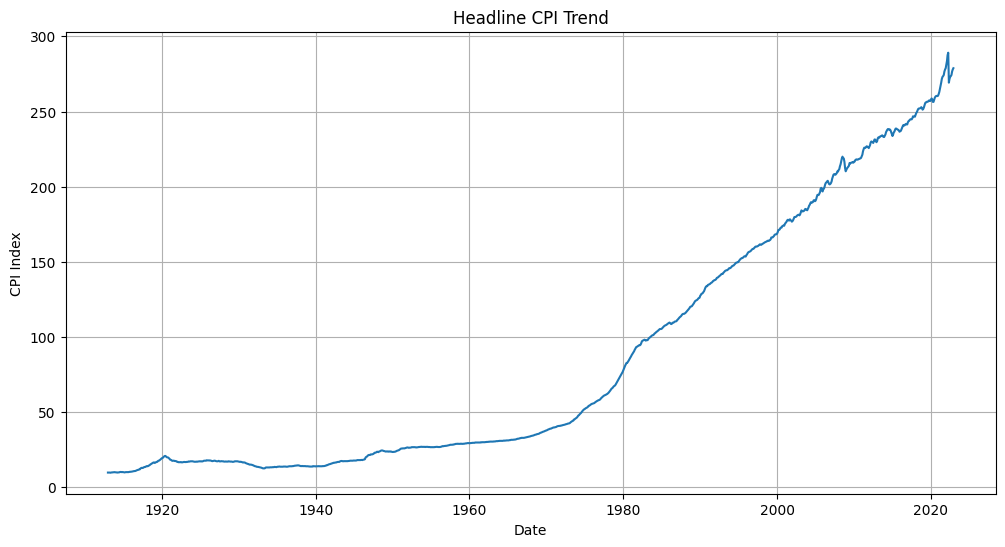

In [4]:
# Rename column properly
df.rename(columns={"Inflation": "CPI"}, inplace=True)

plt.figure(figsize=(12,6))
plt.plot(df.index, df["CPI"])
plt.title("Headline CPI Trend")
plt.xlabel("Date")
plt.ylabel("CPI Index")
plt.grid(True)
plt.show()

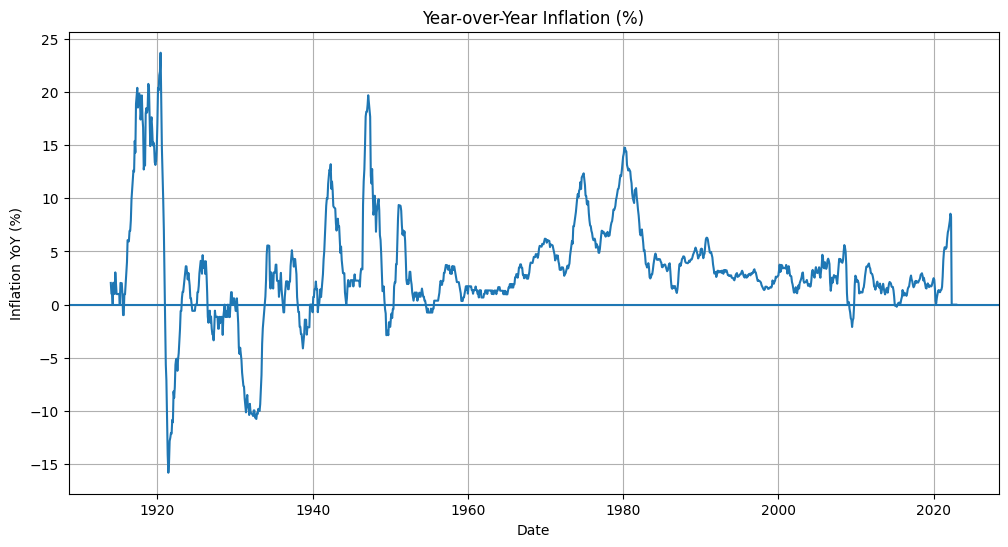

In [5]:
df.columns = df.columns.str.strip().str.lower()

df.index = pd.to_datetime(df.index)
df.sort_index(inplace=True)

df["inflation_yoy"] = df["cpi"].pct_change(12) * 100

plt.figure(figsize=(12,6))
plt.plot(df.index, df["inflation_yoy"])

plt.title("Year-over-Year Inflation (%)")
plt.xlabel("Date")
plt.ylabel("Inflation YoY (%)")

plt.axhline(0)
plt.grid(True)
plt.show()

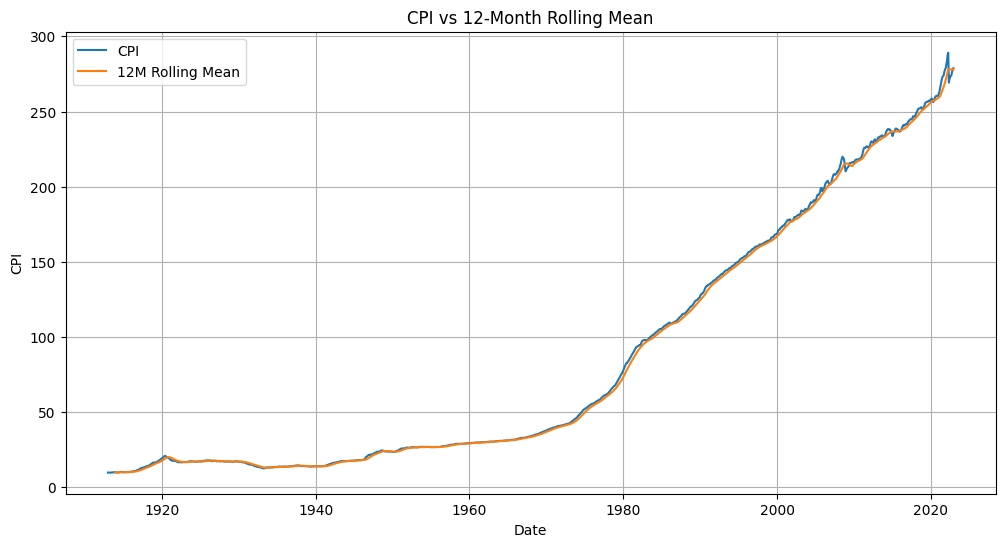

In [6]:

df.columns = df.columns.str.strip().str.lower()

df.index = pd.to_datetime(df.index)
df.sort_index(inplace=True)

df.rename(columns={"inflation": "cpi"}, inplace=True)

df["rolling_mean_12"] = df["cpi"].rolling(window=12).mean()

plt.figure(figsize=(12,6))

plt.plot(df.index, df["cpi"], label="CPI")
plt.plot(df.index, df["rolling_mean_12"], label="12M Rolling Mean")

plt.title("CPI vs 12-Month Rolling Mean")
plt.xlabel("Date")
plt.ylabel("CPI")

plt.legend()
plt.grid(True)

plt.show()

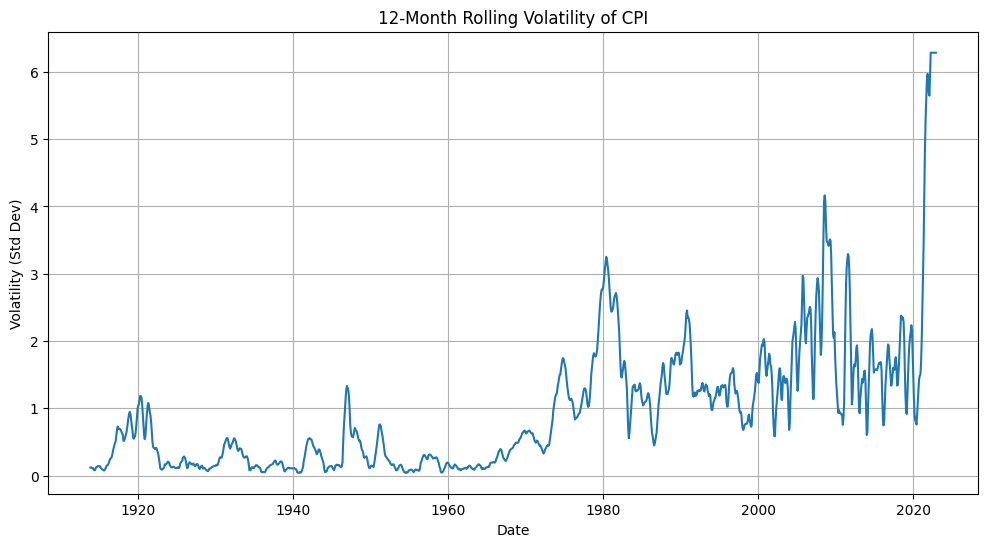

In [7]:
df.columns = df.columns.str.strip().str.lower()

df.index = pd.to_datetime(df.index)
df.sort_index(inplace=True)

if "inflation" in df.columns:
    df.rename(columns={"inflation": "cpi"}, inplace=True)

df["rolling_mean_12"] = df["cpi"].rolling(window=12).mean()

df["rolling_std_12"] = df["cpi"].rolling(window=12).std()

plt.figure(figsize=(12,6))

plt.plot(df.index, df["rolling_std_12"])

plt.title("12-Month Rolling Volatility of CPI")
plt.xlabel("Date")
plt.ylabel("Volatility (Std Dev)")

plt.grid(True)
plt.show()

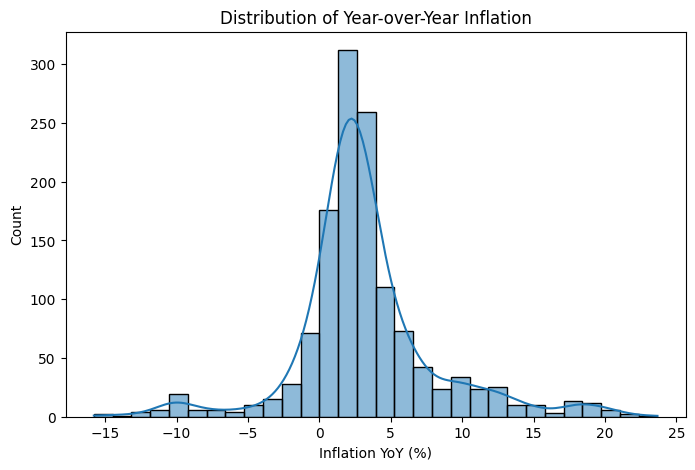

In [8]:
df.columns = df.columns.str.strip().str.lower()

if "inflation_yoy" not in df.columns:
    df["inflation_yoy"] = df["cpi"].pct_change(12) * 100

plt.figure(figsize=(8,5))

sns.histplot(df["inflation_yoy"].dropna(), bins=30, kde=True)

plt.title("Distribution of Year-over-Year Inflation")
plt.xlabel("Inflation YoY (%)")

plt.show()

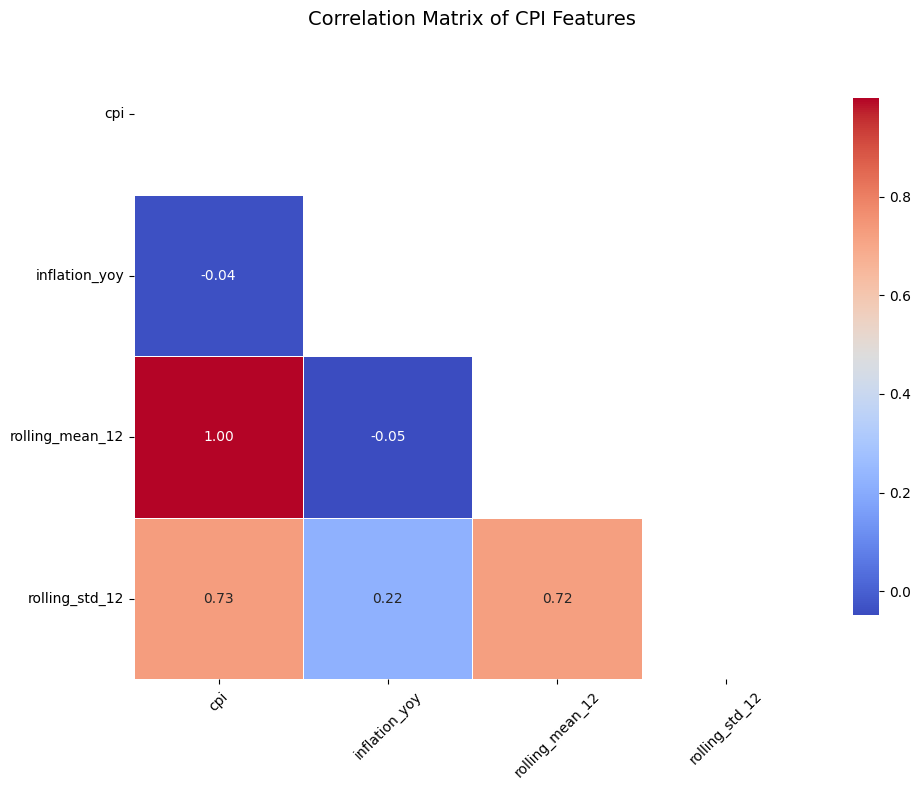

In [9]:
numeric_df = df.select_dtypes(include=["float64", "int64"])

corr_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of CPI Features", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

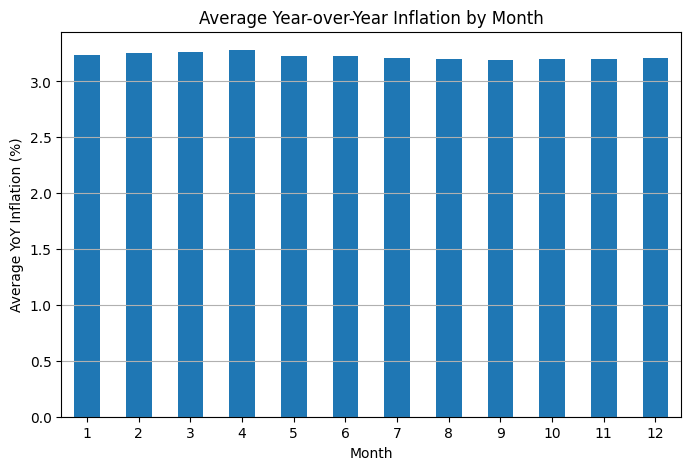

In [10]:
df.columns = df.columns.str.strip().str.lower()

df.index = pd.to_datetime(df.index)

if "inflation_yoy" not in df.columns:
    df["inflation_yoy"] = df["cpi"].pct_change(12) * 100

df["month"] = df.index.month

monthly_avg = df.groupby("month")["inflation_yoy"].mean()

plt.figure(figsize=(8,5))

monthly_avg.plot(kind="bar")

plt.title("Average Year-over-Year Inflation by Month")
plt.xlabel("Month")
plt.ylabel("Average YoY Inflation (%)")

plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

In [11]:
df.columns = df.columns.str.strip().str.lower()

if "inflation_yoy" not in df.columns:
    df["inflation_yoy"] = df["cpi"].pct_change(12) * 100

inflation_series = df["inflation_yoy"].dropna()

top_spikes = inflation_series.abs().sort_values(ascending=False).head(10)

top_spikes_with_sign = df.loc[top_spikes.index, "inflation_yoy"]

top_spikes_with_sign

Date
1920-06-01    23.668639
1920-05-01    21.893491
1920-04-01    21.556886
1918-11-01    20.740741
1918-12-01    20.437956
1920-02-01    20.370370
1917-06-01    20.370370
1920-03-01    20.121951
1917-09-01    19.819820
1947-03-01    19.672131
Name: inflation_yoy, dtype: float64

## Key Observations

- CPI shows long-term upward trend
- Inflation exhibits cyclical behavior
- Volatility clusters during economic stress
- Strong correlation between lag features and current CPI
- Evidence of seasonality in monthly inflation
- Structural spikes align with macroeconomic shocks

--------------------------------------------------------------